# Bag of Words Meets Bags of Popcorn Sentiment Analysis

In [1]:

import warnings
warnings.filterwarnings('ignore')

from collections import Counter

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords
from textblob import TextBlob
from bs4 import BeautifulSoup

nltk.download('stopwords')

import gensim
from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.svm import LinearSVC, SVC

from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingClassifier
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization,
    Embedding, GlobalAveragePooling1D,
    LSTM, Bidirectional,
    Conv1D, GlobalMaxPooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MONSTER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
train = pd.read_csv('labeledTrainData.tsv.zip',sep='\t', quoting=3)
label = pd.read_csv('unlabeledTrainData.tsv.zip',sep='\t', quoting=3)
test = pd.read_csv('testData.tsv.zip',sep='\t', quoting=3)

In [3]:
train.head()

,id,sentiment,review
0,"""5814_8""",1,"""With all this stuff going down at the moment ..."
1,"""2381_9""",1,"""\""The Classic War of the Worlds\"" by Timothy ..."
2,"""7759_3""",0,"""The film starts with a manager (Nicholas Bell..."
3,"""3630_4""",0,"""It must be assumed that those who praised thi..."
4,"""9495_8""",1,"""Superbly trashy and wondrously unpretentious ..."



 sentiment
1    12500
0    12500
Name: count, dtype: int64


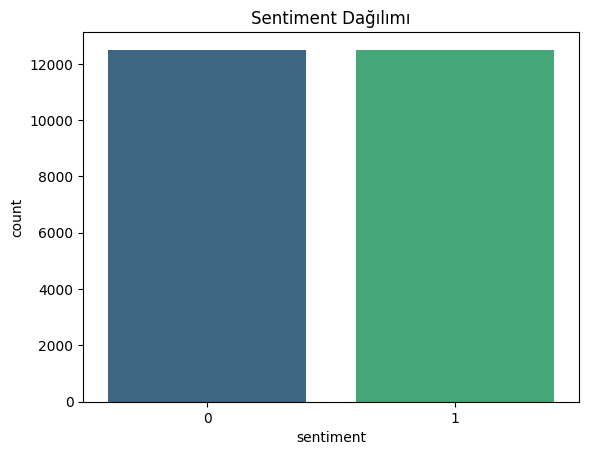

In [4]:
print("\n", train['sentiment'].value_counts())
sns.countplot(x='sentiment', data=train, palette='viridis')
plt.title("Sentiment Dağılımı")
plt.show()

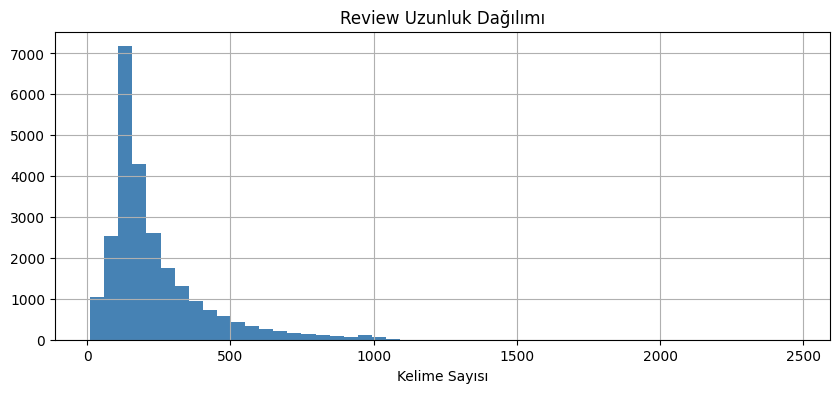

In [5]:
train['review_len'] = train['review'].apply(lambda x: len(str(x).split()))
train['review_len'].hist(bins=50, figsize=(10,4), color='steelblue')
plt.title("Review Uzunluk Dağılımı")
plt.xlabel("Kelime Sayısı")
plt.show()

In [6]:
stop_words = set(stopwords.words('english'))

In [7]:
def clean_text(text):
    text = BeautifulSoup(text, 'html.parser').get_text()  # HTML kaldır
    text = re.sub(r'[^a-zA-Z]', ' ', text)                # sadece harf
    text = text.lower()                                   # küçük harf
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]   # stopword kaldır
    return ' '.join(tokens)

In [8]:
train['review'] = train['review'].apply(clean_text)
label['review'] = label['review'].apply(clean_text)
test['review'] = test['review'].apply(clean_text)

In [9]:
train['review'][1]

'classic war worlds timothy hines entertaining film obviously goes great effort lengths faithfully recreate h g wells classic book mr hines succeeds watched film appreciated fact standard predictable hollywood fare comes every year e g spielberg version tom cruise slightest resemblance book obviously everyone looks different things movie envision amateur critics look criticize everything others rate movie important bases like entertained people never agree critics enjoyed effort mr hines put faithful h g wells classic novel found entertaining made easy overlook critics perceive shortcomings'

In [10]:
x = train['review']
y = train['sentiment']

In [11]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [12]:
tfidf = TfidfVectorizer(max_features=10000,ngram_range=(1, 2),sublinear_tf=True,stop_words='english')

In [13]:
x_train_tf  = tfidf.fit_transform(x_train)
x_val_tf = tfidf.transform(x_val)
x_test_tf = tfidf.transform(test['review'])

In [14]:
modeller = {
    'BernoulliNB'              : BernoulliNB(),
    'LogisticRegression'       : LogisticRegression(),
    'DecisionTreeClassifier'   : DecisionTreeClassifier(),
    'RandomForestClassifier'   : RandomForestClassifier(),
    'GradientBoostingClassifier': GradientBoostingClassifier(),
    'KNeighborsClassifier'     : KNeighborsClassifier(),
    'AdaBoostClassifier'       : AdaBoostClassifier(),
    'MultinomialNB'            : MultinomialNB(),
}

sonuclar = {}

for isim, model in modeller.items():
    model.fit(x_train_tf, y_train)
    tahmin = model.predict(x_val_tf)
    
    sonuclar[isim] = {
        'Accuracy' : accuracy_score(y_val, tahmin),
        'Precision': precision_score(y_val, tahmin, average='micro'),
        'Recall'   : recall_score(y_val, tahmin, average='micro'),
        'F1'       : f1_score(y_val, tahmin, average='micro'),
    }
    print(f"{isim}: {sonuclar[isim]['F1']:.4f}")

metrics = pd.DataFrame(sonuclar).T.sort_values('F1', ascending=False)
print(metrics)
print(f"\nEn iyi model: {metrics.index[0]}")

BernoulliNB: 0.8542
LogisticRegression: 0.8872
DecisionTreeClassifier: 0.7128
RandomForestClassifier: 0.8472
GradientBoostingClassifier: 0.8058
KNeighborsClassifier: 0.7914
AdaBoostClassifier: 0.7470
MultinomialNB: 0.8646
                            Accuracy  Precision  Recall      F1
LogisticRegression            0.8872     0.8872  0.8872  0.8872
MultinomialNB                 0.8646     0.8646  0.8646  0.8646
BernoulliNB                   0.8542     0.8542  0.8542  0.8542
RandomForestClassifier        0.8472     0.8472  0.8472  0.8472
GradientBoostingClassifier    0.8058     0.8058  0.8058  0.8058
KNeighborsClassifier          0.7914     0.7914  0.7914  0.7914
AdaBoostClassifier            0.7470     0.7470  0.7470  0.7470
DecisionTreeClassifier        0.7128     0.7128  0.7128  0.7128

En iyi model: LogisticRegression


In [15]:
model = LogisticRegression()
model.fit(x_train_tf, y_train)
best_pred = model.predict(x_val_tf)

print(classification_report(y_val, best_pred,
      target_names=['negative', 'positive']))

              precision    recall  f1-score   support

    negative       0.90      0.87      0.89      2500
    positive       0.88      0.90      0.89      2500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000



In [16]:
x = tfidf.fit_transform(train['review'])

In [17]:
model.fit(x, y)
final_pred = model.predict(x_test_tf)

submission = pd.DataFrame({
    'id'       : test['id'],
    'sentiment': final_pred
})

In [18]:
submission.to_csv('submission.csv', index=False)

In [19]:
submission.head()

,id,sentiment
0,"""12311_10""",1
1,"""8348_2""",0
2,"""5828_4""",1
3,"""7186_2""",1
4,"""12128_7""",1


In [20]:
submission['id'] = submission['id'].str.replace('"', '')
submission.head()

,id,sentiment
0,12311_10,1
1,8348_2,0
2,5828_4,1
3,7186_2,1
4,12128_7,1


In [22]:
import joblib

joblib.dump(model, "bagofwords_model.pkl")

['bagofwords_model.pkl']